In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from pathlib import Path
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.ensemble import ExtraTreesRegressor

# Setup aesthetics
sns.set_theme(style='whitegrid')
plt.style.use("default")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# 1. Load the newly built mega-dataset
data_path = '../../data/processed/unified_environment_focus_dataset.csv'
df = pd.read_csv(data_path, parse_dates=["timestamp"], low_memory=False)

print("UNIFIED DATASET LOADED")
print(f"Total Rows: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")
print(f"Unique Sources: {df['source'].nunique()}")

display(df.head())

UNIFIED DATASET LOADED
Total Rows: 1,028,189
Total Columns: 11
Unique Sources: 4


,timestamp,session_id,location_id,record_id,source,humidity,light,temperature,noise,co2,focus_score
0,2013-08-23 15:00:00+00:00,keti_1min_resampled__511__s00001,511,keti_1min_resampled:row_00204742,keti_1min_resampled,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-08-23 15:01:00+00:00,keti_1min_resampled__511__s00001,511,keti_1min_resampled:row_00204743,keti_1min_resampled,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-08-23 15:02:00+00:00,keti_1min_resampled__511__s00001,511,keti_1min_resampled:row_00204744,keti_1min_resampled,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-08-23 15:03:00+00:00,keti_1min_resampled__511__s00001,511,keti_1min_resampled:row_00204745,keti_1min_resampled,NaN,NaN,NaN,NaN,NaN,NaN
4,2013-08-23 15:04:00+00:00,keti_1min_resampled__511__s00001,511,keti_1min_resampled:row_00204746,keti_1min_resampled,NaN,NaN,NaN,NaN,NaN,NaN


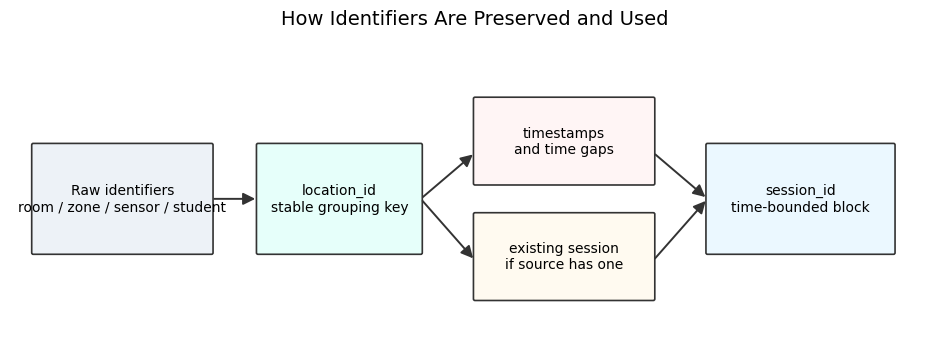

In [3]:
def draw_box(ax, xy, width, height, text, color):
    box = FancyBboxPatch(
        xy,
        width,
        height,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=1.2,
        edgecolor="#333333",
        facecolor=color,
    )
    ax.add_patch(box)
    ax.text(
        xy[0] + width / 2,
        xy[1] + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=10,
        wrap=True,
    )

def draw_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=1.4,
        color="#333333",
    )
    ax.add_patch(arrow)

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.axis("off")

draw_box(ax, (0.3, 1.25), 2.3, 1.4, "Raw identifiers\nroom / zone / sensor / student", "#edf2f7")
draw_box(ax, (3.2, 1.25), 2.1, 1.4, "location_id\nstable grouping key", "#e6fffa")
draw_box(ax, (6.0, 2.15), 2.3, 1.1, "timestamps\nand time gaps", "#fff5f5")
draw_box(ax, (6.0, 0.65), 2.3, 1.1, "existing session\nif source has one", "#fffaf0")
draw_box(ax, (9.0, 1.25), 2.4, 1.4, "session_id\ntime-bounded block", "#ebf8ff")

draw_arrow(ax, (2.6, 1.95), (3.2, 1.95))
draw_arrow(ax, (5.3, 1.95), (6.0, 2.55))
draw_arrow(ax, (5.3, 1.95), (6.0, 1.15))
draw_arrow(ax, (8.3, 2.55), (9.0, 1.95))
draw_arrow(ax, (8.3, 1.15), (9.0, 1.95))

ax.set_title("How Identifiers Are Preserved and Used", fontsize=14, pad=12)
plt.show()

## 2. Session Integrity Check

Our pipeline script grouped continuous time-series data into chunks called `session_id`s, breaking them apart if there was a gap longer than 2 hours. 

Here we perform a strict QA check to ensure that:
1. No session accidentally mixes different locations or sources.
2. No session contains internal time gaps larger than our 120-minute threshold.

Total Unique Sessions: 74
Sessions checked: 74
Problem sessions: 0


,session_id,problem


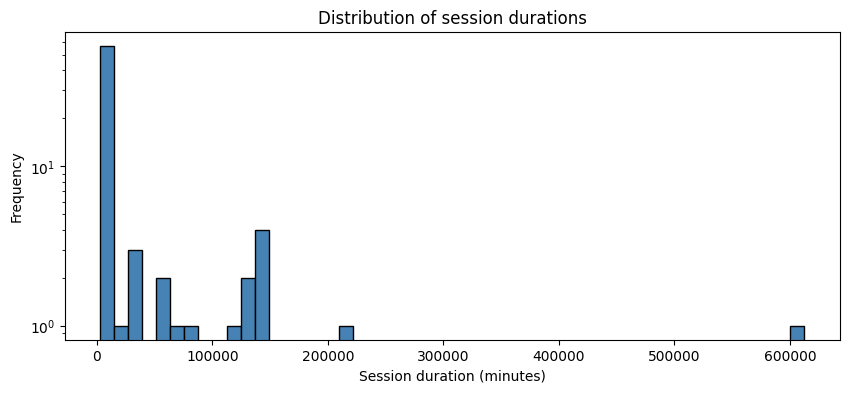

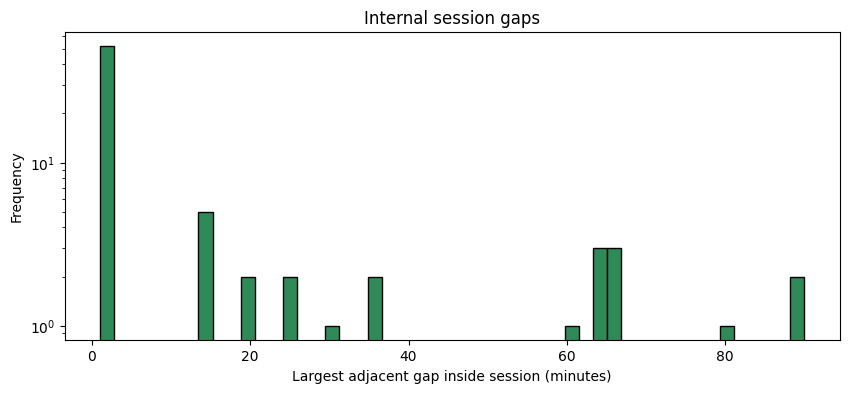

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# distinct values of session_id
print(f"Total Unique Sessions: {df['session_id'].nunique():,}")

# For each session, check that it stays within one source/location and that
# adjacent timestamps inside a session do not cross the 2-hour split threshold.
session_groups = df.sort_values(['source', 'location_id', 'timestamp']).groupby('session_id')
timediffs = []
max_internal_gaps = []
bad_sessions = []

for session_id, group in session_groups:
    source_count = group['source'].nunique()
    location_count = group['location_id'].nunique()
    if source_count > 1 or location_count > 1:
        bad_sessions.append((session_id, 'multiple source/location values'))

    timestamp_diff = group['timestamp'].max() - group['timestamp'].min()
    timediffs.append(timestamp_diff.total_seconds() / 60)

    gaps = group['timestamp'].sort_values().diff().dropna()
    if not gaps.empty:
        max_gap_minutes = gaps.max().total_seconds() / 60
        max_internal_gaps.append(max_gap_minutes)
        if max_gap_minutes > 120:
            bad_sessions.append((session_id, f'internal gap {max_gap_minutes:.1f} minutes'))

print(f'Sessions checked: {len(timediffs):,}')
print(f'Problem sessions: {len(bad_sessions):,}')
display(pd.DataFrame(bad_sessions, columns=['session_id', 'problem']).head(20))

plt.figure(figsize=(10, 4))
plt.hist(timediffs, bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Session duration (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of session durations')
plt.yscale('log')
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(max_internal_gaps, bins=50, color='seagreen', edgecolor='black')
plt.xlabel('Largest adjacent gap inside session (minutes)')
plt.ylabel('Frequency')
plt.title('Internal session gaps')
plt.yscale('log')
plt.show()

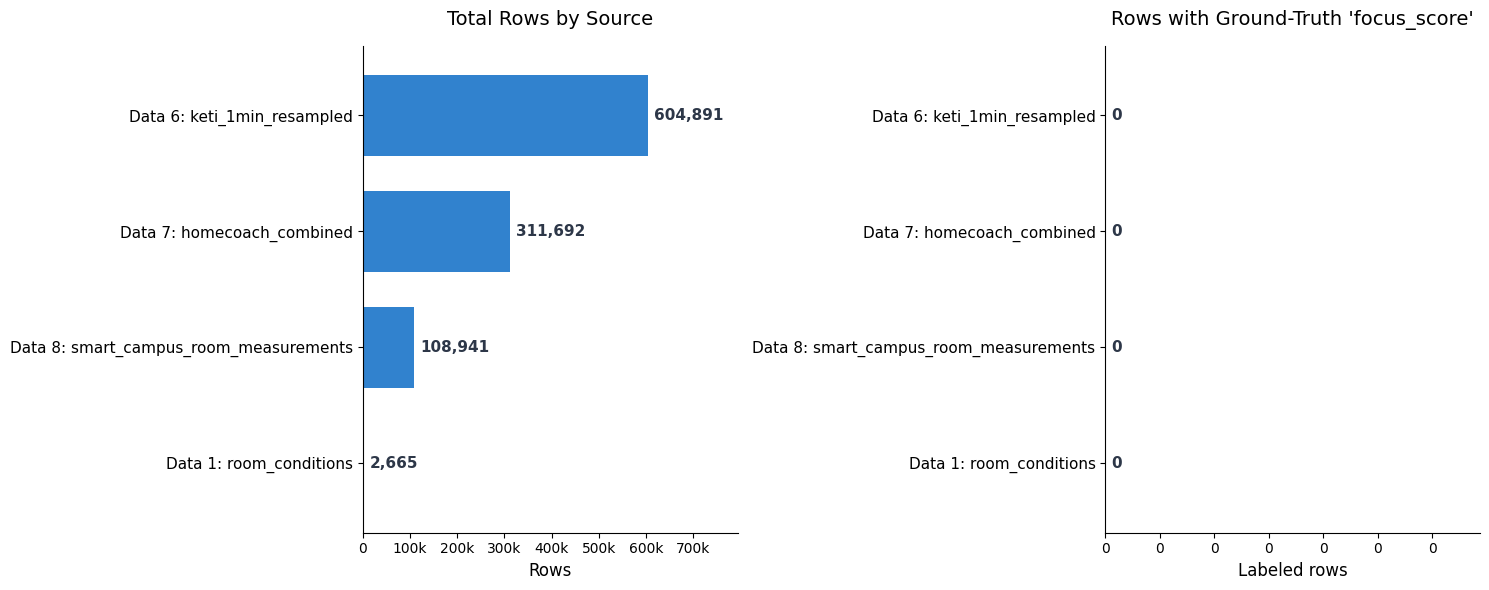

In [5]:
import matplotlib.ticker as ticker

# 1. Create a mapping dictionary to make the names look professional
name_mapping = {
    "room_conditions": "Data 1: room_conditions",
    "keti_1min_resampled": "Data 6: keti_1min_resampled",
    "homecoach_combined": "Data 7: homecoach_combined",
    "smart_campus_room_measurements": "Data 8: smart_campus_room_measurements"
}

# Aggregate rows and labels by source
source_summary = df.groupby("source").agg(
    rows=("record_id", "count"),
    labeled_rows=("focus_score", lambda values: int(values.notna().sum())),
    locations=("location_id", "nunique"),
    sessions=("session_id", "nunique"),
).sort_values("rows", ascending=True)

# 2. Rename the index using our dictionary
source_summary.index = source_summary.index.map(lambda x: name_mapping.get(x, x))

# Increased height slightly for better vertical breathing room
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot total rows 
source_summary["rows"].plot(kind="barh", ax=axes[0], color="#3182ce", width=0.7)
axes[0].set_title("Total Rows by Source", fontsize=14, pad=15)
axes[0].set_xlabel("Rows", fontsize=12)
axes[0].set_ylabel("")

# Plot labeled rows 
source_summary["labeled_rows"].plot(kind="barh", ax=axes[1], color="#38a169", width=0.7)
axes[1].set_title("Rows with Ground-Truth 'focus_score'", fontsize=14, pad=15)
axes[1].set_xlabel("Labeled rows", fontsize=12)
axes[1].set_ylabel("")

# --- THE BULLETPROOF FIX: Custom "k" Formatter ---
# This turns 100000 into "100k", making the bottom axis super clean
def format_thousands(value, tick_number):
    if value >= 1000:
        return f'{int(value/1000)}k'
    return str(int(value))

formatter = ticker.FuncFormatter(format_thousands)

axes[0].xaxis.set_major_formatter(formatter)
axes[1].xaxis.set_major_formatter(formatter)
# -------------------------------------------------

# 3. Add exact numbers next to the bars
for p in axes[0].patches:
    axes[0].text(
        p.get_width() + (axes[0].get_xlim()[1] * 0.02),
        p.get_y() + p.get_height() / 2,     
        f'{int(p.get_width()):,}',         
        va='center', 
        ha='left', 
        fontsize=11,
        fontweight='bold',
        color='#2d3748' 
    )

# 4. Add exact numbers next to the bars
for p in axes[1].patches:
    axes[1].text(
        p.get_width() + (axes[1].get_xlim()[1] * 0.02), 
        p.get_y() + p.get_height() / 2, 
        f'{int(p.get_width()):,}', 
        va='center', 
        ha='left', 
        fontsize=11,
        fontweight='bold',
        color='#2d3748'
    )

# 5. Expand the x-axis limits slightly so the text doesn't get cut off
axes[0].set_xlim(0, axes[0].get_xlim()[1] * 1.25)
axes[1].set_xlim(0, axes[1].get_xlim()[1] * 1.25)

# Remove top and right spines for a cleaner, modern look
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.show()

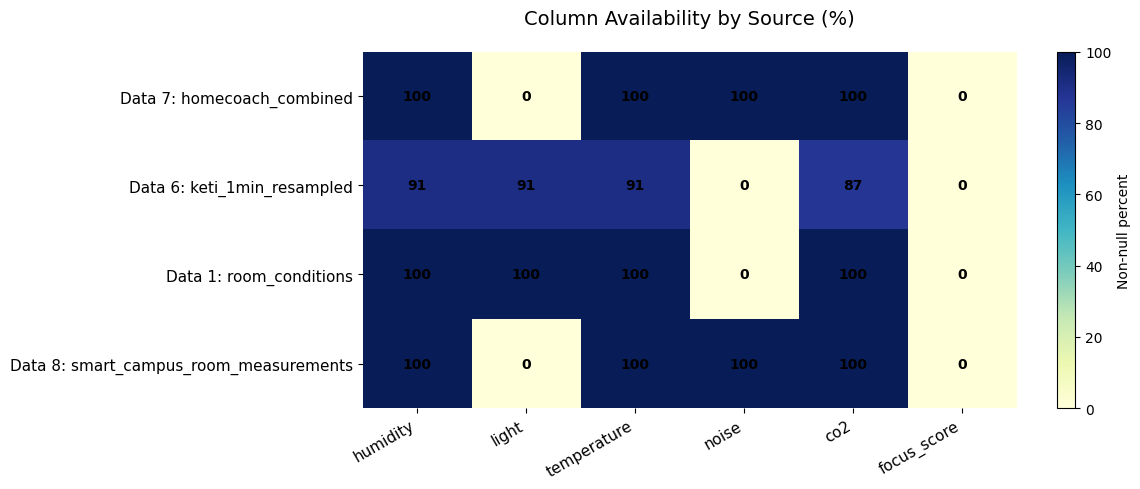

In [6]:
# 1. Reuse our professional mapping dictionary
name_mapping = {
    "room_conditions": "Data 1: room_conditions",
    "keti_1min_resampled": "Data 6: keti_1min_resampled",
    "homecoach_combined": "Data 7: homecoach_combined",
    "smart_campus_room_measurements": "Data 8: smart_campus_room_measurements"
}

model_columns = ["humidity", "light", "temperature", "noise", "co2", "focus_score"]

availability_by_source = df.groupby("source")[model_columns].apply(lambda part: part.notna().mean() * 100)

# 2. Apply the dictionary to rename the datasets
availability_by_source.index = availability_by_source.index.map(lambda x: name_mapping.get(x, x))

# 3. Slightly increased width (12) to fit the new longer dataset names
fig, ax = plt.subplots(figsize=(12, 5))
image = ax.imshow(availability_by_source.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=100)

ax.set_xticks(np.arange(len(model_columns)))
ax.set_xticklabels(model_columns, rotation=30, ha="right", fontsize=11)
ax.set_yticks(np.arange(len(availability_by_source.index)))
ax.set_yticklabels(availability_by_source.index, fontsize=11) # The new names render here!
ax.set_title("Column Availability by Source (%)", pad=20, fontsize=14)

for row in range(availability_by_source.shape[0]):
    for col in range(availability_by_source.shape[1]):
        value = availability_by_source.iloc[row, col]
        # Made the numbers slightly larger and bolder for readability
        ax.text(col, row, f"{value:.0f}", ha="center", va="center", fontsize=10, fontweight='bold')

# Remove top, right, and bottom borders for a modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

fig.colorbar(image, ax=ax, label="Non-null percent")
plt.tight_layout()
plt.show()

Outlier Detection Report:


,column,non_null_rows,lower_bound,upper_bound,outlier_count,outlier_pct
1,light,551265,-36.88,70.79,102633,18.62
4,co2,949476,55.88,972.88,121478,12.79
2,temperature,971876,17.84,27.33,63118,6.49
0,humidity,971886,37.02,71.66,20700,2.13
3,noise,420592,5.00,77.00,250,0.06


C:\Users\piotr\AppData\Local\Temp\ipykernel_27860\3067918014.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, vert=False, labels=top_cols, showfliers=True)


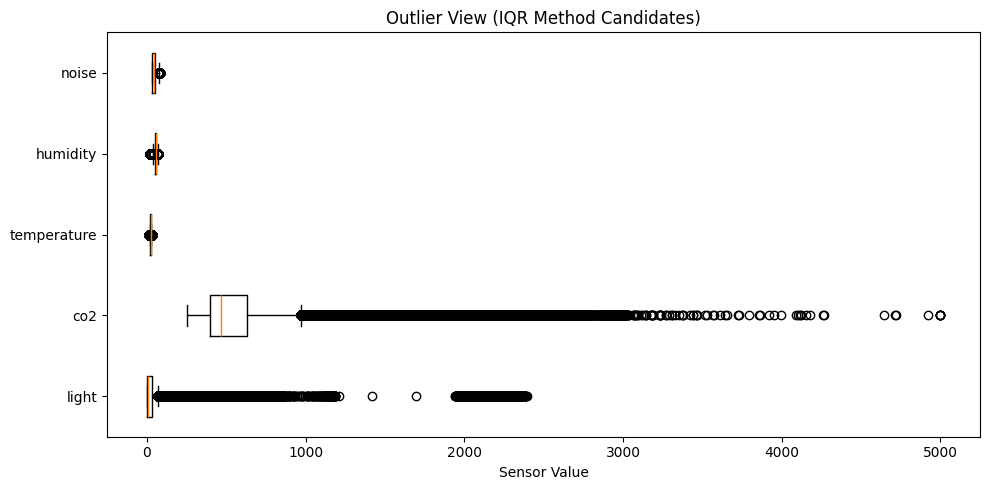

In [7]:
numeric_df = df[model_columns].apply(pd.to_numeric, errors="coerce")

if numeric_df.empty:
    print("No numeric columns found for outlier analysis.")
else:
    outlier_stats = []
    for column in numeric_df.columns:
        series = numeric_df[column].dropna()
        if series.empty:
            continue

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 if iqr == 0 else q1 - 1.5 * iqr
        upper = q3 if iqr == 0 else q3 + 1.5 * iqr
        
        outliers = ((series < lower) | (series > upper)).sum()
        outlier_pct = (outliers / len(series)) * 100 if len(series) else 0

        outlier_stats.append({
            "column": column,
            "non_null_rows": len(series),
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(outliers),
            "outlier_pct": float(outlier_pct),
        })

    outlier_df = pd.DataFrame(outlier_stats).sort_values(by="outlier_pct", ascending=False)
    print("Outlier Detection Report:")
    display(outlier_df)

    # Plot top candidate columns with outliers
    top_cols = outlier_df[outlier_df["outlier_count"] > 0].head(6)["column"].tolist()
    if top_cols:
        plot_data = [numeric_df[column].dropna() for column in top_cols]
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.boxplot(plot_data, vert=False, labels=top_cols, showfliers=True)
        ax.set_title("Outlier View (IQR Method Candidates)")
        ax.set_xlabel("Sensor Value")
        plt.tight_layout()
        plt.show()

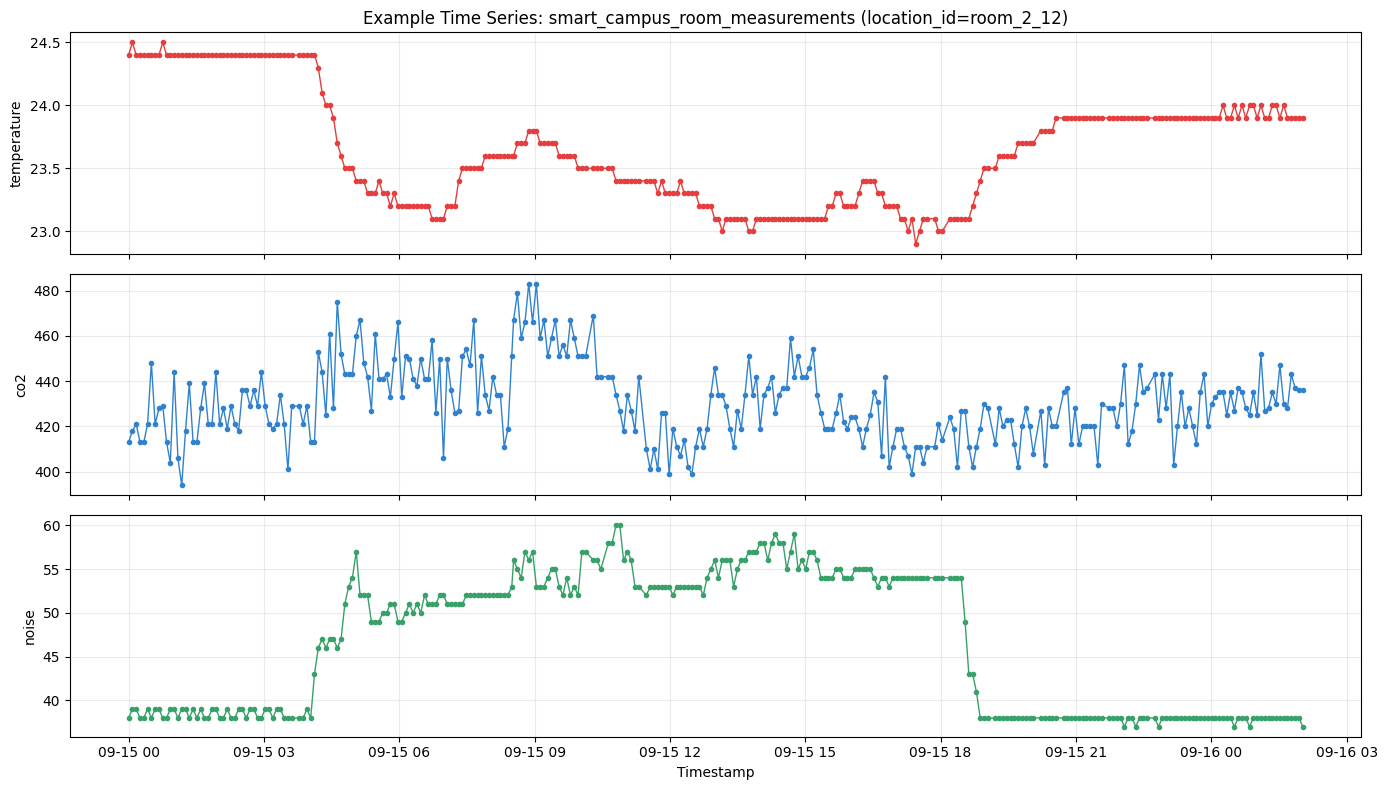

In [8]:
# Pick the largest dataset as an example
example_source = "smart_campus_room_measurements" if "smart_campus_room_measurements" in set(df["source"]) else df["source"].iloc[0]
example_location = df.loc[df["source"].eq(example_source), "location_id"].mode().iloc[0]

# Grab 300 sequential rows
example = df[df["source"].eq(example_source) & df["location_id"].eq(example_location)].sort_values("timestamp").head(300)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, column, color in zip(axes, ["temperature", "co2", "noise"], ["#e53e3e", "#3182ce", "#38a169"]):
    if column in example and example[column].notna().any():
        ax.plot(example["timestamp"], example[column], marker="o", markersize=3, linewidth=1, color=color)
    ax.set_ylabel(column)
    ax.grid(True, alpha=0.25)

axes[0].set_title(f"Example Time Series: {example_source} (location_id={example_location})")
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

In [9]:
print(df.head(10))


                  timestamp                        session_id location_id  \
0 2013-08-23 15:00:00+00:00  keti_1min_resampled__511__s00001         511   
1 2013-08-23 15:01:00+00:00  keti_1min_resampled__511__s00001         511   
2 2013-08-23 15:02:00+00:00  keti_1min_resampled__511__s00001         511   
3 2013-08-23 15:03:00+00:00  keti_1min_resampled__511__s00001         511   
4 2013-08-23 15:04:00+00:00  keti_1min_resampled__511__s00001         511   
5 2013-08-23 15:05:00+00:00  keti_1min_resampled__511__s00001         511   
6 2013-08-23 15:06:00+00:00  keti_1min_resampled__511__s00001         511   
7 2013-08-23 15:07:00+00:00  keti_1min_resampled__511__s00001         511   
8 2013-08-23 15:08:00+00:00  keti_1min_resampled__511__s00001         511   
9 2013-08-23 15:09:00+00:00  keti_1min_resampled__511__s00001         511   

                          record_id               source  humidity  light  \
0  keti_1min_resampled:row_00204742  keti_1min_resampled       NaN    NaN  

In [10]:
# count how many values are missing in each column and print the names of columns with missing values, including percantages
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).sort_values(by="missing_count", ascending=False).reset_index().rename(columns={"index": "column"})
display(missing_summary)

,column,missing_count,missing_pct
0,focus_score,1028189,100.00
1,noise,607597,59.09
2,light,476924,46.38
3,co2,78713,7.66
4,temperature,56313,5.48
5,humidity,56303,5.48
6,timestamp,0,0.00
7,location_id,0,0.00
8,session_id,0,0.00
9,record_id,0,0.00


Before we aggressively drop rows, we need to analyze **why** there are so many missing environmental readings. Are these random sensor glitches, or is there a systematic pattern? 

Let's isolate the rows where our core environmental features (`temperature`, `humidity`, and `co2`) are completely missing, see which datasets they come from, and figure out what data they actually contain.

In [11]:
# Find rows where the core 3 features are ALL missing
missing_env_mask = df[['temperature', 'humidity', 'co2']].isna().all(axis=1)
missing_env_df = df[missing_env_mask]

print(f"Total rows completely missing Temp/Humidity/CO2: {len(missing_env_df):,}\n")

if len(missing_env_df) > 0:
    # 1. Which dataset do these rows come from?
    source_counts = missing_env_df['source'].value_counts()
    display(source_counts.to_frame("Count of Empty Environmental Rows"))
    
    # 2. What columns actually have data in these rows?
    populated_columns = missing_env_df.dropna(axis=1, how='all').columns.tolist()
    print(f"\nColumns populated in these rows: {populated_columns}")

Total rows completely missing Temp/Humidity/CO2: 54,730



,Count of Empty Environmental Rows
source,
keti_1min_resampled,54730



Columns populated in these rows: ['timestamp', 'session_id', 'location_id', 'record_id', 'source']


**Conclusion & Next Steps**

As our analysis above proves, the vast majority of missing environmental values (~5–8% of the total dataset) come from KETI timestamps that only recorded motion (PIR) events. 

Because Outside of those empty KETI rows, the percentage of data missing just *one* of our core sensors is exceptionally small (well under 3%) of the dataset we decided to remove those rows. It is also because later we want to find out different type of rooms where those 3 features are more or less correlated with each other, so it would not make sense to impute those 3% rows values due to redundancy and overcomplicating the solution. **Therefore, it is safe to drop them.**

In [12]:
# remove rows where either co2, temperature, or humidity are missing
df = df.dropna(subset=['co2', 'temperature', 'humidity'])

missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).sort_values(by="missing_count", ascending=False).reset_index().rename(columns={"index": "column"})
display(missing_summary)

,column,missing_count,missing_pct
0,focus_score,947898,100.00
1,noise,527330,55.63
2,light,420594,44.37
3,location_id,0,0.00
4,session_id,0,0.00
5,timestamp,0,0.00
6,record_id,0,0.00
7,humidity,0,0.00
8,source,0,0.00
9,temperature,0,0.00


## Imputing missing Light and Noise values
Run KMeans clustering algorithm to group data into room types based on 3 feature (temperature, humidity, CO2). Using elbow method to find reasonable number of clusters.

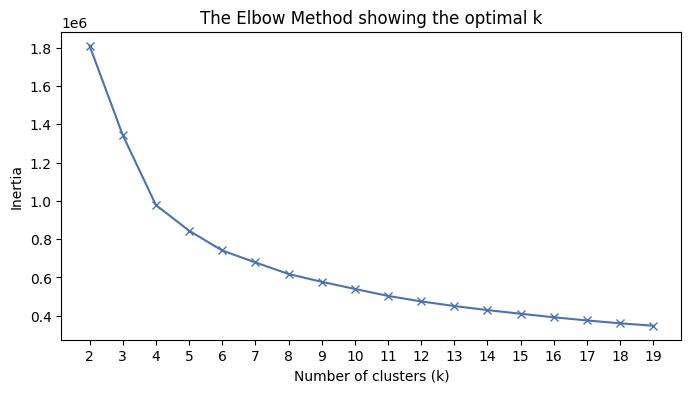

In [13]:
combined_df = df.copy()


# We use these 3 to group similar rows together
anchors = ['temperature', 'humidity', 'co2']

# Scale the data (Standardize) so CO2 doesn't drown out Temperature
scaled_data = StandardScaler().fit_transform(combined_df[anchors])


from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2, 20) # Test from 2 to 20 clusters

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data) # Use your scaled anchor data
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.xticks(K)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.show()



In [14]:
%pip install plotly
%pip install matplotlib
%pip install nbformat

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\piotr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\piotr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\piotr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
import plotly.express as px
import pandas as pd
from sklearn.cluster import KMeans

# --- 4. INTERACTIVE 3D VISUALIZATION (k=4) ---

# Define the choice
k_choice = 4
max_points = 15000 

# 1. Generate the clustering model specifically for k=4
km_final = KMeans(n_clusters=k_choice, random_state=42, n_init=10)
labels = km_final.fit_predict(scaled_data)

# 2. Create the full DataFrame first
# We ensure 'Cluster' is a standard column so Plotly can find it
full_plot_df = pd.DataFrame(scaled_data, columns=['Temp', 'Humidity', 'CO2'])
full_plot_df['Cluster'] = labels.astype(str)

# 3. Downsample: If we have more than our limit, take a random sample
if len(full_plot_df) > max_points:
    print(f"Sampling {max_points} points from {len(full_plot_df)} for performance...")
    plot_df = full_plot_df.sample(n=max_points, random_state=42)
else:
    plot_df = full_plot_df

# 4. Generate the interactive plot
fig = px.scatter_3d(
    plot_df, 
    x='Temp', 
    y='Humidity', 
    z='CO2',
    color='Cluster', # This matches the column name added above
    title=f'Interactive 3D Cluster Map (k={k_choice}) - Sampled Data',
    opacity=0.6, 
    template='plotly_dark' 
)

# Optimize the markers for performance
fig.update_traces(marker=dict(size=3)) 

fig.show()

Sampling 15000 points from 947898 for performance...


Using elbow method and analysing the 3d graph, 4 clusters were picked because that is where the improvement starts to level off (adding more clusters than 4 is not dropping inertia significantly enough), so adding more would just make the model more complex without actually helping much. 

## Impute Light and Noise
We utilized an IterativeImputer with an ExtraTreesRegressor backend. Unlike standard linear MICE, ExtraTrees captures non-linear interactions between variables (e.g., $CO_2$ spikes as a proxy for occupancy affecting light). For "dead" clusters, where `Light` or `Noise` are 100% missing, we applied a Global Median fallback. This is a deliberate design choice to handle extreme data sparsity, without at least some local ground truth, a model cannot statistically converge on a meaningful correlation, and a robust central tendency (median) is used to prevent model bias.

In [16]:
# This class modifies ExtraTreesRegressor by teaching the Forest how to calculate 
# uncertainty (std).
class SmartForest(ExtraTreesRegressor):
    def predict(self, X, return_std=False):
        if not return_std:
            return super().predict(X)
        # We ask every tree in the forest for its guess
        all_preds = np.stack([t.predict(X) for t in self.estimators_])
        # Return the average and the "disagreement" (standard deviation)
        return np.mean(all_preds, axis=0), np.std(all_preds, axis=0)

model_kmeans = KMeans(n_clusters=4, random_state=42)
combined_df['room_type'] = model_kmeans.fit_predict(scaled_data)

# Columns to use for imputation in the new dataset
impute_cols = ['co2', 'noise', 'temperature', 'light', 'humidity']
missing_impute_cols = [col for col in impute_cols if col not in combined_df.columns]
if missing_impute_cols:
    raise ValueError(f"Missing required columns for imputation: {missing_impute_cols}")

# --- 3. MOCKING LIGHT AND NOISE (STREAMLINED ROBUST LOOP) ---

imputed_chunks = []

# We go through every group found by KMeans
for room_id in sorted(combined_df['room_type'].unique()):
    print(f"Processing Cluster {room_id}...")
    
    # Get the rows for just this group
    chunk = combined_df[combined_df['room_type'] == room_id].copy()
    original_backup = chunk.copy()
    
    # Create the imputer
    mice = IterativeImputer(
        estimator=SmartForest(
            n_estimators=20, 
            max_depth=15, 
            min_samples_leaf=5, 
            random_state=42
        ),
        sample_posterior=True, 
        n_nearest_features=5,
        random_state=42
    )
    
    # 1. Limit to the columns we want to use for imputation
    numbers_only = [col for col in impute_cols if col in chunk.columns]
    
    # 2. Identify which sensors are active vs. 100% missing in this cluster
    active_cols = [col for col in numbers_only if chunk[col].notna().any()]
    dropped_cols = list(set(numbers_only) - set(active_cols))
    
    # Printout to see exactly what is happening in each cluster
    if dropped_cols:
        print(f"  ⚠️  Cluster {room_id}: Skipping sensor(s) {dropped_cols} (100% missing in this cluster)")
    else:
        print(f"  ✅  Cluster {room_id}: All sensors present. Running full smart imputation.")
    
    # 3. Run the Imputation
    # (No 'if' check needed here because Temp, Hum, and CO2 are pre-filled)
    filled_data = mice.fit_transform(chunk[active_cols])
    temp_df = pd.DataFrame(filled_data, columns=active_cols, index=chunk.index)
    
    # --- PHYSICAL BOUNDARY FIX ---
    if 'light' in temp_df.columns:
        temp_df['light'] = temp_df['light'].clip(lower=0)
    if 'noise' in temp_df.columns:
        temp_df['noise'] = temp_df['noise'].clip(lower=0)
    
    # --- PROTECTION: RESTORE THE ORIGINAL DATA ---
    # We only want the imputed Light and Noise. Everything else stays pure.
    for col in active_cols:
        if col in ['temperature', 'humidity', 'co2']:
            temp_df[col] = original_backup[col].values
            
    # Re-add non-imputed columns and any skipped sensors
    for col in chunk.columns:
        if col not in temp_df.columns:
            temp_df[col] = original_backup[col].values
    
    imputed_chunks.append(temp_df)

# --- 4. FINAL GLUE AND SAFETY NET ---

# Combine all the groups and sort them back into the original order
final_df = pd.concat(imputed_chunks).sort_index()

# THE SAFETY NET: Fill any sensors that were 100% dead in a cluster with the global median
final_df['light'] = final_df['light'].fillna(combined_df['light'].median())
final_df['noise'] = final_df['noise'].fillna(combined_df['noise'].median())

# Apply the final column order for the new dataset
final_cols = [
    'timestamp',
    'session_id',
    'location_id',
    'record_id',
    'source',
    'humidity',
    'light',
    'temperature',
    'noise',
    'co2',
    'focus_score'
 ]
final_df = final_df[final_cols]

print("\n--- Final Imputation Complete ---")
print(f"Missing values remaining: {final_df[['light', 'noise']].isna().sum().sum()}")

# --- 5. VISUAL CHECK ---

print("\nTop of your new dataset:")
print(final_df.head())



Processing Cluster 0...
  ✅  Cluster 0: All sensors present. Running full smart imputation.
Processing Cluster 1...
  ✅  Cluster 1: All sensors present. Running full smart imputation.
Processing Cluster 2...
  ✅  Cluster 2: All sensors present. Running full smart imputation.
Processing Cluster 3...
  ✅  Cluster 3: All sensors present. Running full smart imputation.

--- Final Imputation Complete ---
Missing values remaining: 0

Top of your new dataset:
               timestamp                         session_id location_id  \
1669 2013-08-23 23:04:00   keti_1min_resampled__510__s00001         510   
1670 2013-08-23 23:04:00   keti_1min_resampled__511__s00001         511   
1674 2013-08-23 23:04:00   keti_1min_resampled__558__s00001         558   
1676 2013-08-23 23:04:00   keti_1min_resampled__621__s00001         621   
1677 2013-08-23 23:04:00  keti_1min_resampled__621a__s00001        621a   

                             record_id               source  humidity  light  \
1669  keti_1

## Variance and distribution check
Compare the standard deviation of original vs mocked `light` and `noise` to see if the synthetic values keep a similar spread.

In [17]:
#comparison std of light and noise
print("The standard deviation of the original light is:", combined_df['light'].std())
print("The standard deviation of the mocked light is:", final_df['light'].std())
print("The standard deviation of the original noise is:", combined_df['noise'].std())
print("The standard deviation of the mocked noise is:", final_df['noise'].std())

The standard deviation of the original light is: 315.1843886060607
The standard deviation of the mocked light is: 337.8674166712028
The standard deviation of the original noise is: 10.301697839176269
The standard deviation of the mocked noise is: 9.05950641712433


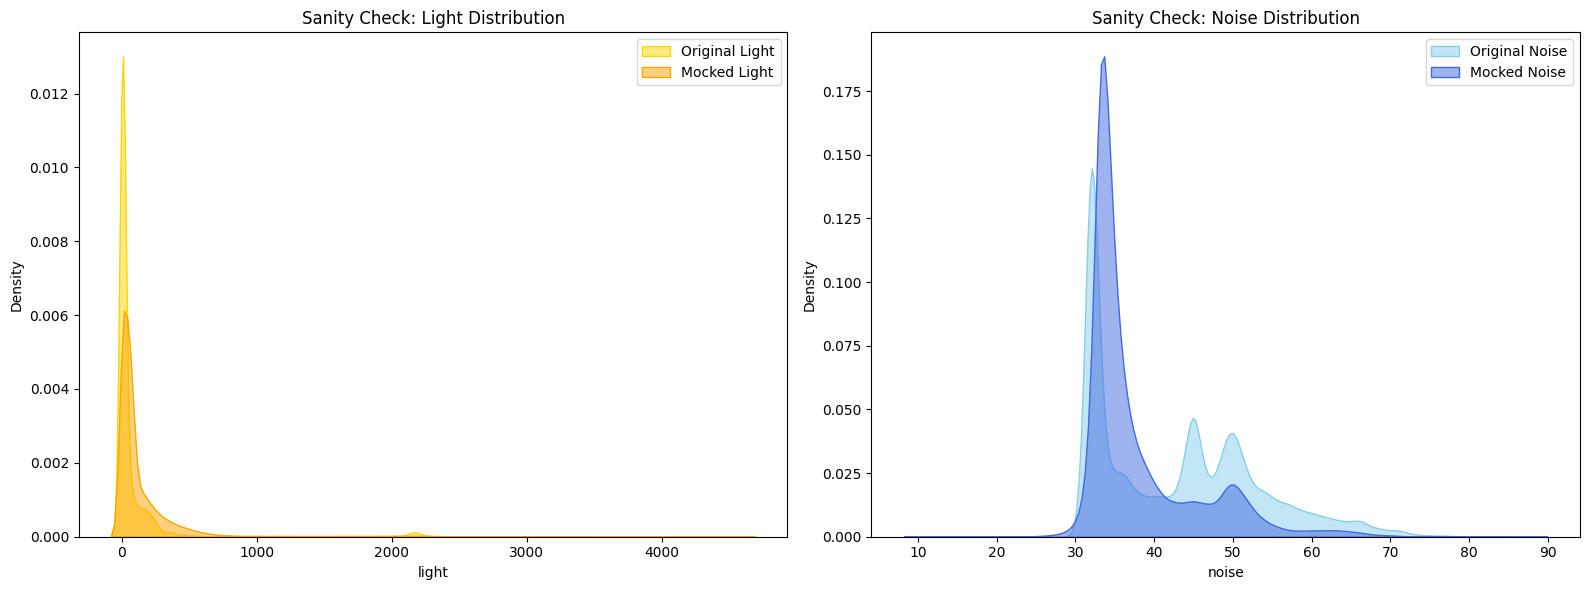

In [18]:
# Plot the distribution to check the 'texture' of the mocked data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: LIGHT DISTRIBUTION ---
sns.kdeplot(combined_df['light'].dropna(), ax=ax1, label='Original Light', fill=True, alpha=0.5, color='gold')
sns.kdeplot(final_df.loc[combined_df['light'].isna(), 'light'], ax=ax1, label='Mocked Light', fill=True, alpha=0.5, color='orange')
ax1.set_title('Sanity Check: Light Distribution')
ax1.legend()

# --- PLOT 2: NOISE DISTRIBUTION ---
sns.kdeplot(combined_df['noise'].dropna(), ax=ax2, label='Original Noise', fill=True, alpha=0.5, color='skyblue')
sns.kdeplot(final_df.loc[combined_df['noise'].isna(), 'noise'], ax=ax2, label='Mocked Noise', fill=True, alpha=0.5, color='royalblue')
ax2.set_title('Sanity Check: Noise Distribution')
ax2.legend()

plt.tight_layout()
plt.show()

## Handling outliers

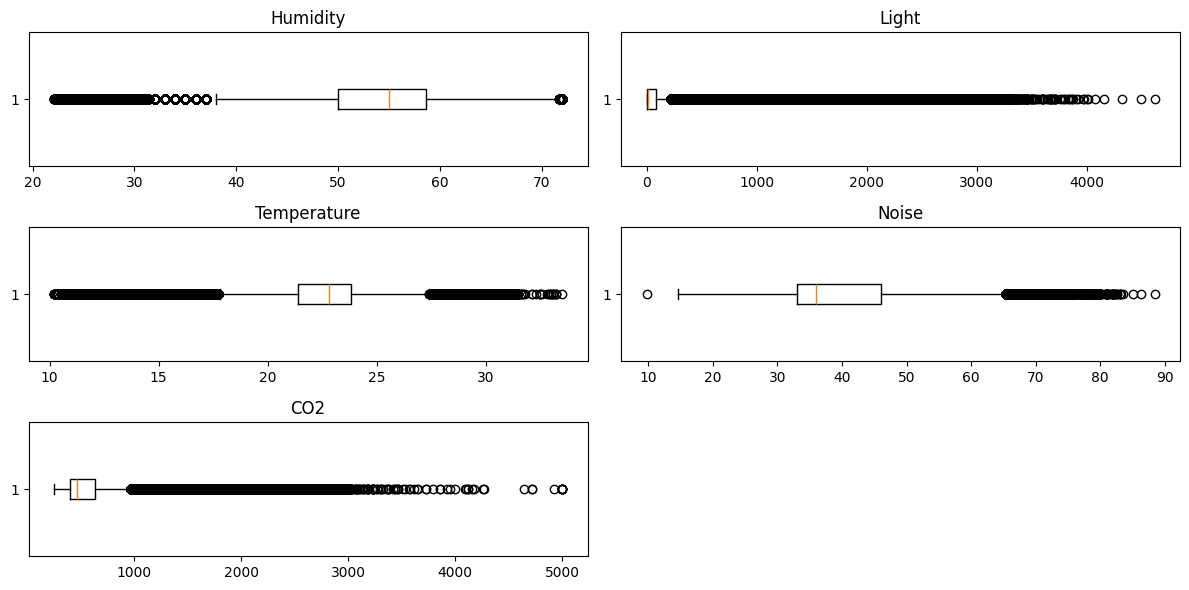

In [19]:
plt.figure(figsize=(12, 6))

plt.subplot(3,2,1)
plt.boxplot(final_df['humidity'], vert=False)
plt.title("Humidity")

plt.subplot(3,2,2)
plt.boxplot(final_df['light'], vert=False)
plt.title("Light")

plt.subplot(3,2,3)
plt.boxplot(final_df['temperature'], vert=False)
plt.title("Temperature")

plt.subplot(3,2,4)
plt.boxplot(final_df['noise'], vert=False)
plt.title("Noise")

plt.subplot(3,2,5)
plt.boxplot(final_df['co2'], vert=False)
plt.title("CO2")

plt.tight_layout()
plt.show()

We keep all data because none of the outliers looks like erros more like rare events that we want to include in the training process of the model later. However, transformation of skeweness is needed and done.

In [20]:
#transforming co2 with reciprocal
final_df['co2'] = 1/final_df['co2']

#transforming light with log
final_df['light'] = np.log1p(final_df['light'])

#transforming noise with square root
final_df['noise'] = np.sqrt(final_df['noise'])

#transforming humidity power
final_df['humidity'] = final_df['humidity']**2

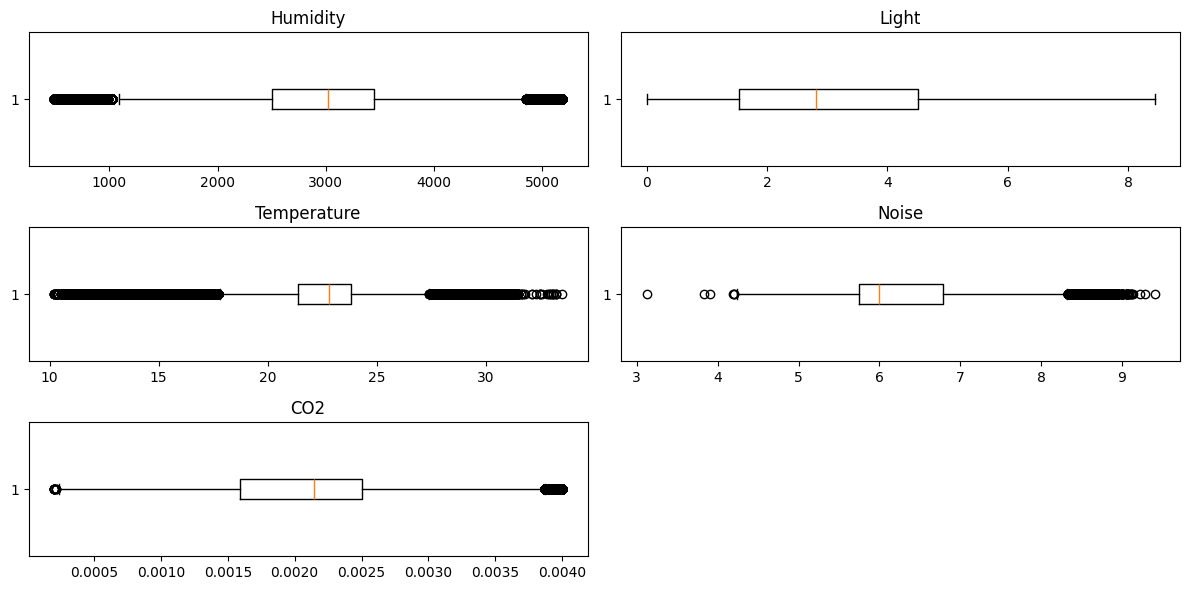

In [21]:
plt.figure(figsize=(12, 6))

plt.subplot(3,2,1)
plt.boxplot(final_df['humidity'], vert=False)
plt.title("Humidity")

plt.subplot(3,2,2)
plt.boxplot(final_df['light'], vert=False)
plt.title("Light")

plt.subplot(3,2,3)
plt.boxplot(final_df['temperature'], vert=False)
plt.title("Temperature")

plt.subplot(3,2,4)
plt.boxplot(final_df['noise'], vert=False)
plt.title("Noise")

plt.subplot(3,2,5)
plt.boxplot(final_df['co2'], vert=False)
plt.title("CO2")

plt.tight_layout()
plt.show()

In [22]:
final_df

,timestamp,session_id,location_id,record_id,source,humidity,light,temperature,noise,co2,focus_score
1669,2013-08-23 23:04:00,keti_1min_resampled__510__s00001,510,keti_1min_resampled:row_00192747,keti_1min_resampled,"2,768.86",5.32,23.46,7.12,0.00,NaN
1670,2013-08-23 23:04:00,keti_1min_resampled__511__s00001,511,keti_1min_resampled:row_00205226,keti_1min_resampled,"2,782.56",5.53,22.62,7.10,0.00,NaN
1674,2013-08-23 23:04:00,keti_1min_resampled__558__s00001,558,keti_1min_resampled:row_00257060,keti_1min_resampled,"2,859.04",1.39,23.12,5.65,0.00,NaN
1676,2013-08-23 23:04:00,keti_1min_resampled__621__s00001,621,keti_1min_resampled:row_00293044,keti_1min_resampled,"2,412.28",4.23,25.59,5.96,0.00,NaN
1677,2013-08-23 23:04:00,keti_1min_resampled__621a__s00001,621a,keti_1min_resampled:row_00305039,keti_1min_resampled,"3,050.35",4.84,22.21,6.91,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1028184,2026-05-06 15:27:49,homecoach_combined__homecoach_combined_unknown...,homecoach_combined_unknown_location,homecoach_combined:HomeCoach,homecoach_combined,"2,601.00",1.96,21.70,6.48,0.00,NaN
1028185,2026-05-06 15:32:49,homecoach_combined__homecoach_combined_unknown...,homecoach_combined_unknown_location,homecoach_combined:HomeCoach,homecoach_combined,"2,601.00",0.00,21.70,6.63,0.00,NaN
1028186,2026-05-06 15:37:49,homecoach_combined__homecoach_combined_unknown...,homecoach_combined_unknown_location,homecoach_combined:HomeCoach,homecoach_combined,"2,601.00",3.95,21.70,6.40,0.00,NaN
1028187,2026-05-06 15:42:49,homecoach_combined__homecoach_combined_unknown...,homecoach_combined_unknown_location,homecoach_combined:HomeCoach,homecoach_combined,"2,704.00",2.27,21.80,5.66,0.00,NaN


## End of Exploratory Data Analysis & Final Data Export

We have successfully:
1. Validated the structural integrity of the mega-merged dataset.
2. Dropped the incomplete, motion-only rows from KETI.
3. Clustered the environments to prove our core features (Temp, Humidity, CO2) contain distinct, learnable patterns.

The data is now mathematically clean and ready for target imputation. We will export this cleaned dataset as `final_mock_dataset.csv` so it can pick it up in **Notebook 4**.

In [23]:
output_path = '../../data/processed/final_mock_dataset.csv'

Path(output_path).parent.mkdir(parents=True, exist_ok=True)

print(f"Exporting cleaned mega-dataset to CSV...")
print(f"Final Row Count: {len(df):,}")

# Save the dataframe, dropping the Pandas index so we don't get an unnamed column
df.to_csv(output_path, index=False)

print(f"The data is saved to: {output_path}")
print("Let's proceed to Notebook 4.")

Exporting cleaned mega-dataset to CSV...
Final Row Count: 947,898
The data is saved to: ../../data/processed/final_mock_dataset.csv
Let's proceed to Notebook 4.
